# **Travail pratique 1 SDD1004**
**Yannick Poirier, POIY04109403**



---



# **1 - Visualisation des données avec Python (5 points)**

**À l’aide des bibliothèques Python, créez une ou plusieurs visualisations des
données suivantes et expliquez-les en détail**

In [18]:
import numpy as np
import pandas as pd

np.random.seed(1) # Définition du seed pour la reproductibilité

n_samples = 500 # Définis un échantillon de 500. On peut le modifier selon les besoins de précision

education = np.random.uniform(0, 10, size=n_samples) # Niveau d'éducation (0-10)
income = 2 * education + np.random.normal(0, 1, size=n_samples) # Revenu dépend de l'éducation
health = 3 * income + np.random.normal(0, 1, size=n_samples) # Santé dépend du revenu

# Combinaison en DataFrame
data = pd.DataFrame({
 'Education': education,
 'Income': income,
 'Health': health
})

Explication des données de base : Les données représentent une simulation ou le niveau d'éducation varient entre 0 et 10. Ensuite, nous disons que le revenue ($$$) dépends du niveau d'éducation. Nous effectuons le niveau d'éducation x 2 + du bruit normal. Finalement, nous disons que la santé dépends du revenue. Nous effectuons revenue x 3 + du bruit normal.

Dans un premier temps, j'affiche les 10 premiers échantillons du jeu de données afin d'avoir une idée à quoi ressemble les données et les valeurs. J'affiche ensuite les statistiques de bases (moyenne, écart-type, min/max, etc.). On voit clairement dans notre jeux de données que le niveau d'éducation influence le revenue et que le revenue influence la santé. Par exemple, la ligne 5 est le niveau d'éducation le plus bas avec 0.92, un revenue de 3.61 et une santé de 10.65. La ligne 1 est le niveau d'éducation le plus haut avec 7.20, un revenue de 14.23 et une santé de 44.39.  

In [19]:
data.head(10)

,Education,Income,Health
0,4.170220,8.224455,24.213647
1,7.203245,14.231031,44.398576
2,0.001144,-0.931627,-2.554376
3,3.023326,5.513631,15.541467
4,1.467559,1.508562,4.924286
5,0.923386,3.614732,10.652192
6,1.862602,3.249831,6.695730
7,3.455607,7.388825,22.646327
8,3.967675,6.913464,19.187692
9,5.388167,11.570863,35.291053


In [20]:
data.describe()

,Education,Income,Health
count,500.000000,500.000000,500.000000
mean,5.082771,10.205443,30.648154
std,2.968271,6.062279,18.215250
min,0.001144,-1.406049,-3.688736
25%,2.493964,4.807510,14.269585
50%,5.334093,10.579745,31.656852
75%,7.672182,15.311967,45.611667
max,9.973229,21.576135,65.368004




---



Dans un deuxième temps, j'affiche les nuages de points avec une matrice de graph afin de visuellement voir les relations entre mes variables. Ont peut observer plusieurs choses, notamment :

La diagonale qui contient les histogrammes pour chaque variables ; L'histogramme de l'éducation est uniformément réparti entre 0 et 10. Les histogrammes de revenue et santé ont des distributions normales autours de leur moyenne. Par exemple, la moyenne du revenue est de 10.20 et la moyenne de la santé est de 30.64. Ont peut voir sur les histogrammes que la distribution de ceux-ci sont correspondant avec les moyennes.

Les nuages de points représentent tous des fortes relations linéaires positives entre les variables. On remarque que la relation linéaire est particulièrement forte entre le revenue et la santé, c'est presque une ligne droite avec de très petit écart. C'est la relation la plus forte. On peut aussi remarqué que la relation entre l'éducation et la santé est légèrement un peu plus diffuse puisqu'il y a deux niveaux de bruit qui les séparent. Elle reste tout de même très forte.  

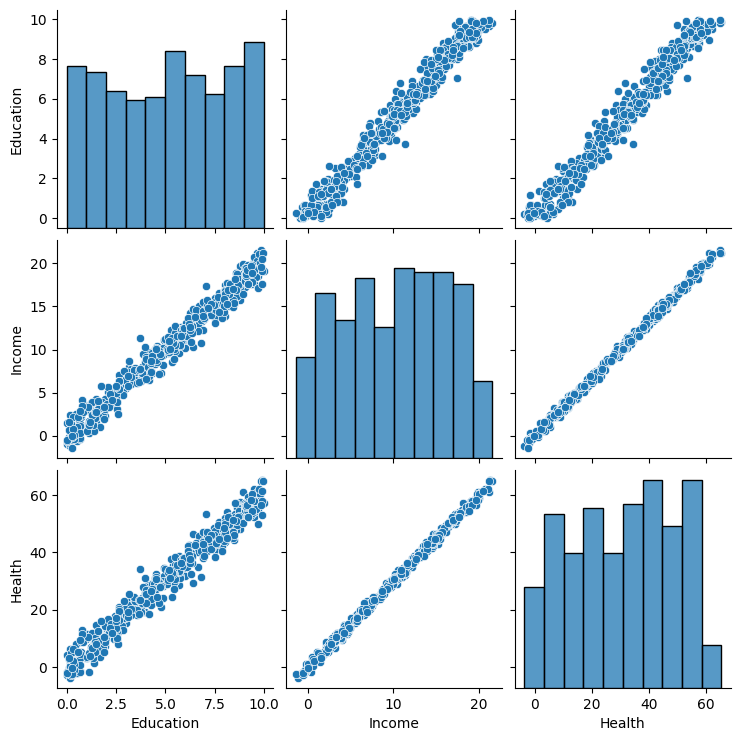

In [21]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.pairplot(data) # Matrice de nuages de points
plt.show()



---



Dans un troisième temps, je crée une heatmap pour voir les corrélations entre chaque variable. La valeur 1.000 représente une parfaite corrélation et 0.000 représente une absence total de corrélation. Le résultat est assez facile à interpréter : il y a une corrélation extrêmement forte et significative entre toutes les variables, voir presque parfaite notamment entre le revenue et la santé avec 0.9985. Bien que la corrélation ne prouve PAS la causalité, elle nous donnes tout de même une base solide pour établir une causalité avec un algorithme par la suite.

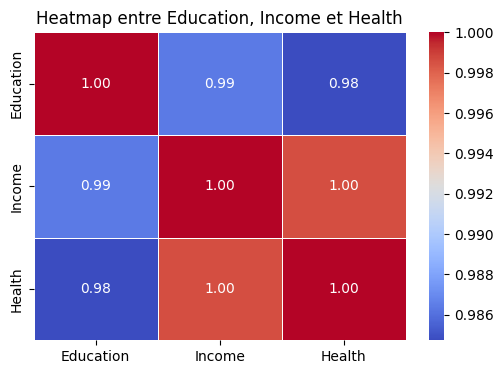

           Education    Income    Health
Education   1.000000  0.986355  0.984733
Income      0.986355  1.000000  0.998592
Health      0.984733  0.998592  1.000000


In [22]:
corr_matrix = data.corr() # Calcul de la matrice de corrélation

# Affichage de la heatmap
plt.figure(figsize=(6, 4))  # Ajuste la taille
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5) # Apparences visuelles de la heatmap

plt.title("Heatmap entre Education, Income et Health")
plt.show()
print(data.corr())



---



Finalement, en m'inspirant de ce que nous avons vue en SDD1002, j'utilise un clustering 3D à l'aide de l'algorithme K-means pour voir s'il y a des sous-groupes distincts. Effectivemment, on observe 3 sous-groupes complètement distinctifs :

Le groupe vert représente les gens avec le moins d'éducation. Ceux-ci ont effectivemment le moins de revenue et le moins de santé.

Le groupe bleu représente les gens avec une éducation qui gravite autours de la moyenne. Le revenue ainsi que la santé tournent également autours de la moyenne. Rappel : La moyenne éducation : 5.08, la moyenne revenue : 10.20, la moyenne santé : 30.64.

Le groupe orange représente les gens le niveau d'éducation le plus élevé et donc le revenue et la santé le plus élevé aussi.

In [23]:
import plotly.express as px
from sklearn.cluster import KMeans


dataCluster1 = data.copy() # Copier data2 dans dataCluster

# Application du clustering K-Means
kmeans = KMeans(n_clusters=3, random_state=43, n_init=10)
dataCluster1["Cluster"] = kmeans.fit_predict(dataCluster1)

# Visualisation interactive en 3D avec Plotly
fig = px.scatter_3d(dataCluster1,
                     x="Education",
                     y="Income",
                     z="Health",
                     color=dataCluster1["Cluster"].astype(str),
                     title="Clustering en 3D des Variables",
                     labels={"Cluster": "Groupe"},
                     opacity=0.8)
fig.show()



---



**Conclusion**

Nous avons un jeu de données pour lequel les statistiques descriptives montrent que l'éducation, le revenu et la santé sont fortement corrélés. Le revenu suit une tendance croissante avec l'éducation avec des variations introduites par une distribution normale. La santé dépend du revenu et suit une dynamique similaire.

Les histogrammes montrent une distribution uniforme pour l'éducation, alors que le revenu et la santé suivent une distribution gaussienne avec des valeurs centrées autours de la moyenne. Les nuages de points révèlent une forte corrélation linéaire positive entre chaque variable.

La matrice de corrélation montrent des valeurs très proche de 1 ce qui confirment une forte interdépendance des variables. Donc, si une variable augmente, les autres ont tendance à augmenter également.

L'algorithme de clustering K-means à permis d'identifier 3 sous-groupes distincts ; un groupe avec une faible éducation, faible revenue et faible santé. Un groupe intermédiaire. Un groupe avec des valeurs élevées dans les 3 dimensions.



---



# **2 - Visualiser et comparer de nouvelles données (5 points)**

**A) Reprenez les étapes de la question 1 pour créer une ou plusieurs visualisations des
données suivantes et expliquez-les en détail.**

**B) Ajoutez une section texte pour expliquer la différence entre la nature des
données ici et celles de la question 1.**

À l'aide du nouveau code fournis pour cette question, je vais reproduire exactement les mêmes étapes de la question 1 afin d'avoir une comparaison identique. Dans un premier temps je vais donc afficher les statistiques de bases. Dans un deuxième temps je vais afficher la matrice de nuage de points. Dans un troisième temps je vais afficher une heatmap. Dans un quatrième temps je vais utilisé l'algorithme K-means pour afficher des clusters 3D. Finalement, je vais discuter à la fin des différences clés observés et du pourquoi.

In [24]:
np.random.seed(3) # Définition du seed pour la reproductibilité

education = np.random.uniform(0, 10, size=n_samples) # Niveau d'éducation (0-10)
income = 2 * education + np.random.normal(0, 1, size=n_samples) # Revenu dépend de l'éducation
health = 3 * abs(np.cos(3 * income)) + 0.5 * abs(np.cos(education))
+ np.random.normal(0, 1, size=n_samples)

# Combinaison en DataFrame
data2 = pd.DataFrame({
 'Education': education,
 'Income': income,
 'Health': health
})

Explication des données de base : L'éducation et le revenue reste inchangé pour ce code. C'est les mêmes lignes de codes que la première question. Le changement est au niveau de la santé. Au lieu de faire revenue x 3 + bruit normale comme dans la question 1, cette fois-ci on fait une transformation trigonométrique puis on ajoute du bruit normale.

3 * abs(np.cos(3 * income) : La santé va donc varier en fonction d'un comportement cyclique de revenue qu'on multiplie par 3 pour accélerer les oscillations du cosinus. Grâce à la fonction abs(), toutes les valeurs du cosinus vont être positives (cela peut simuler des effets positifs sur la santé indépendamment du revenue).

0.5 * abs(np.cos(education)) : Transformation trigonométrique sur la variable éducation en prennant aussi la valeur absolu (donc toujours positif). Cela signifie que le niveau d'éducation a un effet plus faible sur la santé et oscille dans une plage réduite.

Avec les modifications, la relation entre les variables devient plus complexe qu'une simple dépendance linéaire comme la question 1. Il y a maintenant des oscilliations basées sur des fonctions trigonométriques (cosinus) qui simulent un phénomène qui est moins linéaire et plus fluctuants comme la réalité. La santé dépend maintenant non seulement du revenue, mais aussi de l'éducation de manière non-linéaire et avec fluctuations.  

Dans ce nouvelle échantillons de 500 données, on observe que les statistiques des variables éducation et revenue sont très similaire au premier échantillon (ce qui est normal et souhaitable puisque c'est le même code. Exemple : la moyenne d'éducation anciennement de 5.08 vs 4.94 ici). La grande différence est au niveau de la variable santé. Effectivemment, la moyenne est de 2.24 (anciennement 30.64), il n'y a plus de valeur négative (anciennement, min : -3.68 et maintenant min : 0.11) et il n'y a plus de valeur extrême (anciennement, max : 65.36 et maintenant, max : 3.49).

Prenons maintenant la ligne 4 et 8 de data2.head(10). Nous observons en ligne 4 que malgré le niveau d'éducation supérieur à la moyenne (8.92), la santé est très proche de la moyenne (2.48). Inversement, la ligne 8 nous présentes quelqu'un de très inférieure à la moyenne d'éducation (0.51), mais qui possède un score de santé supérieur (2.62) à celui de la ligne 4. Donc, ont peut conclure que les données de santé sont désormais plus variées et moins directement prévisibles.

In [25]:
data2.head(10)

,Education,Income,Health
0,5.507979,11.095050,1.239192
1,7.081478,13.198193,1.305956
2,2.909047,5.907148,1.771643
3,5.108276,10.995449,0.193941
4,8.929470,19.123584,2.481999
5,8.962931,17.045350,2.380790
6,1.255853,2.748112,1.296428
7,2.072429,4.960462,2.272622
8,0.514672,2.890156,2.621458
9,4.408098,9.071787,1.619115


In [26]:
data2.describe()

,Education,Income,Health
count,500.000000,500.000000,500.000000
mean,4.949851,9.919840,2.240777
std,2.814176,5.738377,0.950571
min,0.007455,-2.411244,0.117138
25%,2.574219,4.904883,1.490360
50%,4.909049,10.200588,2.446151
75%,7.278575,14.090126,3.065575
max,9.989384,21.264539,3.499289




---



Je pense que la différence ici est assez flagrante. L'histogramme d'éducation possède une distribution toujours aussi uniforme et l'histogramme du revenu à toujours une distribution normale autours de sa moyenne. On remarque une différence au niveau de l'histogramme pour la santé. Celui-ci affiche une distribution plus irrégulière avec des pics qui se distingue dans la plage de 3 à 3.5.

Concernant les nuages de points, il n'y a pas de changement entre l'éducation et le revenue. Nous observons toujours une forte relation positive (l'augmentation de l'éducation tends à entrainer une augmentation de revenue). Par contre, au niveau de la santé avec l'éducation et le revenue, la relation observé est complètement différente. En effet, il n'est plus possible d'observer directement une relation clair entre les variables. Les nuages de points sont beaucoup plus dispersés (non-linéaire) et ne présentent pas de tendance. Cela met en évidence la nouvelle complexité des relations entre les variables avec une santé qui est beaucoup moins dépendante de manière prévisible.

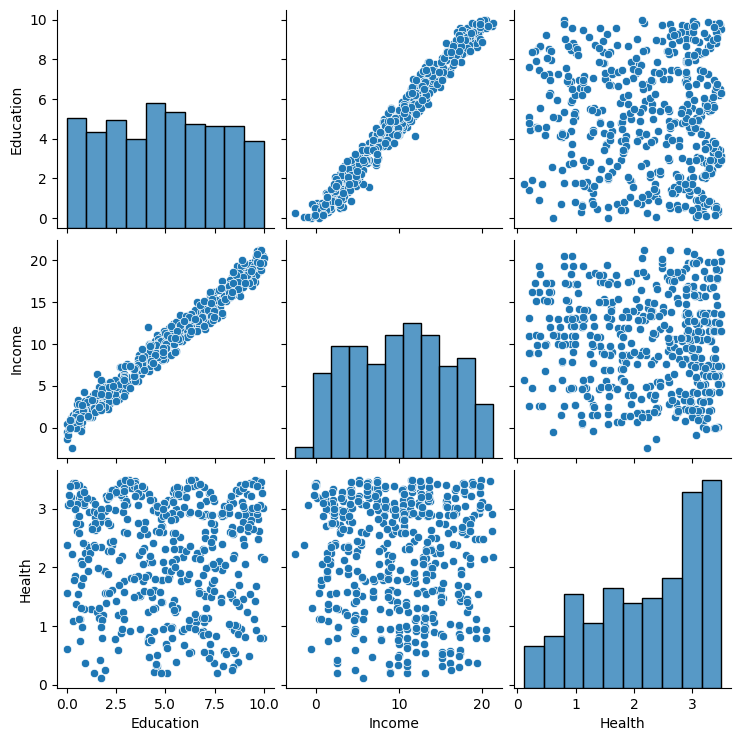

In [27]:
sns.pairplot(data2) # Matrice de nuages de points
plt.show()



---



Pour la section de la heatmap, on observe que la corrélation positive entre l'éducation et le revenue reste extrêmement forte à 0.9851. Cependant, lorsque la santé est l'une des deux variables impliqués, les corrélations sont pratiquemment nulles (-0.078 et -0.087). Cela veut donc dire qu'il n'existe aucune relation linéaire détectable entre la santé et le revenue ou l'éducation. Même si santé est dépendante d'éducation et de revenue, la corrélation n'est plus capable de détecter cette relation. C'est loin d'être presque parfaitement linéaire comme à la question 1.

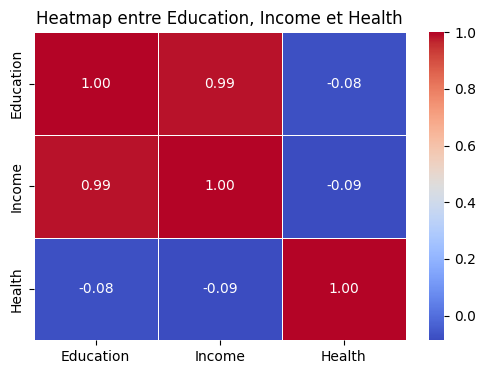

           Education    Income    Health
Education   1.000000  0.985125 -0.078164
Income      0.985125  1.000000 -0.087452
Health     -0.078164 -0.087452  1.000000


In [28]:
corr_matrix = data2.corr() # Calcul de la matrice de corrélation

# Affichage de la heatmap
plt.figure(figsize=(6, 4))  # Ajuste la taille
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5) # Apparences visuelles de la heatmap

plt.title("Heatmap entre Education, Income et Health")
plt.show()
print(data2.corr())



---



Concernant l'algorithme K-means, les résultats obtenus sont bien différent aussi. Nous pouvons toujours observer 3 sous-groupes distincts, mais ils sont définis seulement par la relation entre le niveau d'éducation et le revenue qui est toujours linéaire. Donc, le cluster vert regroupe les gens plus éduquer et avec un revenue plus élevé, le cluster bleu regroupe l'intermédiaire et le cluster orange regroupe les gens avec le moins d'éducation et les revenus les plus bas. L'algorithme est donc toujours capable d'identifier les sous-groupes éducation-revenu, mais santé est éparpillé dans les clusters et n'a pas de frontière claire.

Effectivemment, puisque la santé ne suit plus une tendance linéaire et oscille, les points ne sont plus biens séparés au niveau de santé et sont répartis de manière chaotique, car il n'y a plus de frontière logique et santé est laissé comme une variable fluctuante à l'intérieur de chaque sous-groupe.

In [29]:
dataCluster = data2.copy() # Copier data2 dans dataCluster

# Application du clustering K-Means sur dataCluster
kmeans = KMeans(n_clusters=3, random_state=43, n_init=10)
dataCluster["Cluster"] = kmeans.fit_predict(dataCluster)

# Visualisation interactive en 3D avec Plotly
fig = px.scatter_3d(dataCluster,
                     x="Education",
                     y="Income",
                     z="Health",
                     color=dataCluster["Cluster"].astype(str),
                     title="Clustering en 3D des Variables",
                     labels={"Cluster": "Groupe"},
                     opacity=0.8)
fig.show()



---



**Conclusion**

En conclusion, les variables éducation et revenu restent fortement liées dans la question 1 et 2. Dans la question 2, santé perd toute dépendance et son comportement est plus aléatoire. Cela peut s'observer dans les nuages de points qui sont maintenant dispersés et qui ne forment plus de structure visible avec santé. De plus, nous avons observés que santé est indépendant d'éducation et revenue avec une corrélation négative presque nulle. Finalement, nous avons vue que les clusters avec K-means sont maintenant séparer en sous-groupe uniquement par les variables Éducation-Revenue et que la santé est éparpillé et ne contribue aucunement
a la formation des sous-groupes.

Puisque santé n'est plus une fonction linéaire de revenue, cette façon de procéder est donc beaucoup plus aléatoire et santé fluctue selon une fonction oscillante. Dans un contexte de la vie réelle, il serait maintenant beaucoup plus difficile de prédire l'impact sur la santé qu'aurait une intervention visant une politique éducative (voire impossible à mesurer de cette façon). À la question 1, on pouvait dire : "Augmenter le niveau d'éducation entraîne une hausse de revenus, ce qui améliore la santé" ce qui peut justifier des politiques éducatives comme levier pour le domaine de la santé publique. À la question 2, on ne peut pas l'affirmer comme cela, même si on sait qu'en réalité l'éducation impacte la santé via plusieurs facteurs (accès aux soins, hygiène, nutrition, etc.). C'est pour cela qu'il est important de ne pas se fier uniquement aux corrélations et d'aller un peu plus loin et de bien structurer son analyse.



---



# 3 - Étudier l'algorithme Notears (5 points)


**A) Étudiez l'algorithme Notears() et expliquez pourquoi il n’est pas capable de
trouver les relations entre les données de la question 2.**

**B) Ajoutez vos observations et analysez les limitations de l’algorithme Notears dans
ce contexte**

Je vais d'abord brièvemment définir ce qu'est l'algorithme d'apprentissage nommé Notears (Non-combinatorail Optimization via Trace Exponential and Augmented lagRangian for Structure learning). C'est en fait un algorithme d'apprentissage de graphes causaux qui repose essentiellement sur ; formulation d'un problème d'optimisation continue ; contrainte d'acyclicité différentiable ; Hypothèse souvent implicite de relation (linéaire ou additive) entre variables ou du moins par une structure qui se traduit par des dépendances statistiques détectables.  

En fait, Notears chercher à identifier des liens directs (des arêtes) entre variables en s'appuyant sur des mesures de dépendance qui captent surtout des relations linéaires ou des relations qui se comporte de façon régulière. Si deux variables ne présentent pas de dépendance linéaire, l'algorithme risque de ne pas identifier d'arête les reliant.

**Forces de l'algorithme Notears() :** Méthode puissante et efficace pour des données ou les relations causales se manifestent par des dépendances linéaire. Excellent pour découvrir les DAGs en évitant des tests conditionnels exhaustifs. Donc, dans la question 1, l'algorithme retrouverait sans problème la chaine causale entre les 3 variables.

**Limitations de l'algorithme Notears():** Lorsque la nature des données est non-linéaire, comme c'est le cas pour la question 2, les dépendances statistiques directes entre santé et les autres disparaissent. Notears est concue pour capturer des relations structurées et régulière, il n'est donc pas adapté pour ce type de relation oscillatoire. Les mesures de dépendances (coefficient de régression par exemple) vont être proche de 0 et donc Notear va conclure que santé ne dépend pas d'éducation ou de revenue ; il ne proposera donc pas d'arêtes les reliants dans le DAG.  

**Conclusion :** Notears n'est pas adapté pour la nature des données dans la question 2 à cause de la non-linéarité forte dans la variable santé. Il va échouer pour capturer les dépendances avec santé comme expliquer ci-haut. Cependant, pour la queestion 1, l'algorithme Notear est bien adapté pour trouver les causalités puisque toute les relations sont linéaires et pas d'oscilliation.

En analysant les résultats, on voit effectivemment que la seule relation causale significative trouver est entre l'éducation et le revenue (valeur binaire 1). Cela signifie que l'éducation influence directement le revenue avec un poids significativement élevé selon le seuil détérminé. Ce qui fait du sens puisque c'est la seule relation linéaire avec une corrélation presque parfaite, puisque santé n'est pas impliqué. Une valeur binaire de 0 signifie qu'aucune relation causale n'a été trouvé entre deux variables, ou du moins un poids pas assez significatif selon le seuil qui est déjà bas. L'algorithme d'apprentissage n'a donc pas été capable de trouver une relation entre santé et les 2 autres variables puisque santé est non-linéaire et oscille. C'est pourquoi, un modèle qui n'est pas basé sur la linéarité comme en question 4 va beaucoup mieux performer pour trouver les relations avec les données de la question 2.  

In [30]:
!pip install gcastle

Matrice d'adjacence estimée par NOTEARS :
[[0 1 0]
 [0 0 0]
 [0 0 0]]


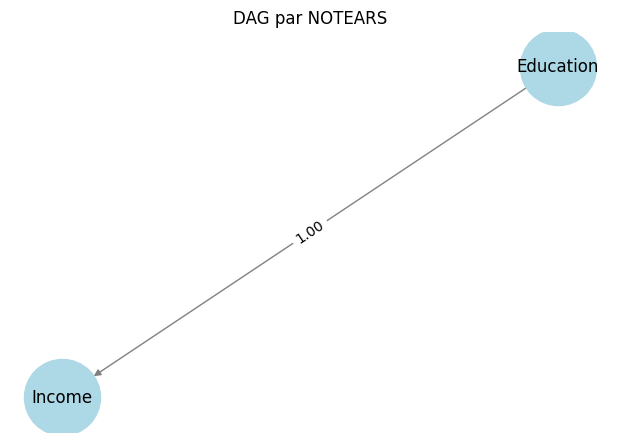

In [36]:
import networkx as nx
from castle.algorithms import Notears

# Chaque colonne de data2 est centrée (moyenne = 0) et réduite (écart-type = 1)
data2_normalized = (data2 - data2.mean()) / data2.std()

# Application de l'algorithme NOTEARS sur les données normalisées
notears = Notears() # Instanciation de l'objet Notears
notears.learn(data2_normalized) # Apprentissage de la structure causale à partir des données normalisées

# Extraction de la matrice d'adjacence estimée par NOTEARS
W = notears.causal_matrix # Récupération de la matrice causale (relations entre les variables)
W = W.T # Transposition de la matrice sinon elle est à l'envers

# Affichage de la matrice d'adjacence
print("Matrice d'adjacence estimée par NOTEARS :")
print(W)

# Création d'un graphe orienté (DAG) avec NetworkX
G = nx.DiGraph() # Création d'un graphe dirigé
variables = list(data2.columns) # Récupération des noms des variables (colonnes) de data2
n = len(variables) # Nombre total de variables
seuil = 1e-3 # Seuil pour filtrer les faibles valeurs

# Parcours de la matrice W pour ajouter des arêtes dans le graphe
for i in range(n):
    for j in range(n):
        # Si le poids de l'arête est supérieur au seuil, on considère qu'il existe une relation causale
        if np.abs(W[i, j]) > seuil:
            # Ajout d'une arête du noeud correspondant à variables[i] vers variables[j] avec le poids W[i, j]
            G.add_edge(variables[i], variables[j], weight=W[i, j])

# Création de la figure pour l'affichage du graphe
plt.figure(figsize=(6, 4))

# Calcul d'un layout pour positionner les noeuds de manière esthétique
pos = nx.spring_layout(G)

# Dessin du graphe : noeuds, arêtes et labels
nx.draw(G, pos, with_labels=True, node_size=3000, node_color="lightblue", edge_color="gray", font_size=12)

# Création des labels pour les arêtes avec le poids affiché à deux décimales
edge_labels = {(u, v): f"{d['weight']:.2f}" for u, v, d in G.edges(data=True)}
nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels)

# Ajout d'un titre à la figure et affichage du graphe
plt.title("DAG par NOTEARS")
plt.show()



---



# 4 - Identifier un algorithme adapté pour la découverte causale (5 points)

**A) Trouvez un algorithme capable de détecter les relations causales dans les données
de la question 2.**

**B) Expliquez le fonctionnement de l'algorithme.**

**C) Implémentez cet algorithme et comparez ses résultats avec ceux obtenus par
Notears.**

**D)  Fournissez une explication détaillée sur les raisons pour lesquelles cet algorithme
est mieux adapté.**

Pour détecter les relations causales dans les données de la question 2, mais cette fois-ci de façon non-linéaire, j'ai opté pour un algorithme dans la même famille que Notears afin de mieux pouvoir comparer les performances de chacun. J'ai choisi l'algorithme Notears-MLP. En fait, c'est un algorithme de Notears, mais qui est non-linéaire et qui utilise un réseau de neurones multi-couche pour apprendre un DAG à partir du jeu de données. Je me suis également intéressé et considérés les algorithmes de : Granger Causality Test, DoWhy, Peter-Clark (PC), Causal Impact, Convergent Cross Mapping (CCM), Structural Equation Modeling (SEM).

Essentiellement, l'algorithme Notears-MLP utilise un réseau de neurones pour trouver des relations non-linéaires entre les variables. Il faut normaliser les données avant tout. Ensuite, plutôt que d'utiliser une simple matrice de poids, ce modèle entraine un réseau de neurones avec des poids aléatoires qui approxime chaque variable comme une fonction non-linéaire des autres variables. Le modèle s'assure de l'absence de cycles dans W en utilisant une contrainte de cycle basée sur la puissance matricielle (c'est une formule mathématique qui garantit qu'il n'y aura aucun cycle). Le modèle est entrainer en minimisant une fonction de perte grâce à une autre formule mathématique qui effectue une optimisation via une descente de gradient avec des mises à jours successives de W, notamment avec régularisation des paramètres L1 (sparsité : seules les relations significatives sont conservées) et L2 (empêche les poids trop grand d'avoir un gros impact). Une fois l'optimisation terminé, la matrice W obtenue contient les poids des relations causales. On applique un seuil (0.01 dans notre contexte) pour filtrer les connexions faibles entre les variables. Si le poids d'une relation est sous le seuil fixé, elle est considéré comme non significative (0). Inversement, si le poids d'une relation est supérieur au seuil, elle est considérer comme significative (1). Finalement, W est interprété comme un DAG. On peut par la suite dessiner un graphe qui représente les relations causales trouvés. Il est possible de jouer avec les paramètres et le seuil selon la précision que nous souhaitons obtenir. Je n'ai toutefois pas remarqué de différence pour ce jeu de données en augmentant ou en diminuant les paramètres et le seuil, les résultats sont les mêmes.  

Je vais effectuer l'implémentation de l'algorithme puis évaluer et comparer les résultats par la suite avec le modèle Notears linéaire.

Matrice d'adjacence non-linéaire :
 [[0 0 1]
 [0 0 1]
 [0 0 0]]


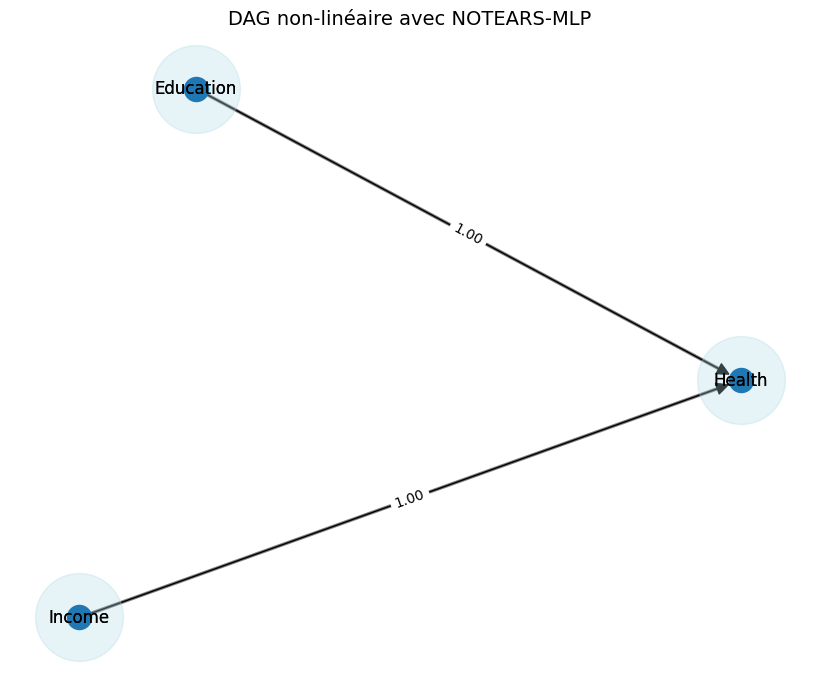

In [37]:
from castle.algorithms import NotearsNonlinear
import networkx as nx
import torch

data2_normalized = (data2 - data2.mean()) / data2.std() # Normalisation des données

# Configuration du modèle Notears non-linéaire avec MLP
notears_nl = NotearsNonlinear(
    model_type='mlp', # Type de modèle (réseaux de neuronnes)
    lambda1=0.001, # Régularisation L1 pour la sparsité (sensibilité du nombre de connexions inutile dans le DAG)
    lambda2=0.0001, # Régularisation L2 (sensibilité qui évite poids extrême en pénalisant grande valeurs)
    max_iter=2000, # Nombre maximal d'itérations
    device_type='gpu' if torch.cuda.is_available() else 'cpu' # Utilisation GPU si disponible pour les calculs, sinon utilise le CPU
)

notears_nl.learn(data2_normalized) # Apprentissage du modèle

W_nl = notears_nl.causal_matrix # Récupération de la matrice d'adjacence
print("Matrice d'adjacence non-linéaire :\n", W_nl) # Affichage de la matrice d'adjacence

# Création du graphe avec NetworkX
G = nx.DiGraph()
variables = data2.columns.tolist() # Liste des variables (noms des colonnes)
threshold = 0.01 # Seuil minimal pour que la relation soit considérer significative

# Ajouter des arêtes si le poids est supérieur au seuil
for i in range(W_nl.shape[0]): # i = variable source
    for j in range(W_nl.shape[1]): # j = variable cible
        if abs(W_nl[i, j]) > threshold: # Ajoute une arête dans le graph si vrai
            G.add_edge(variables[i], variables[j], weight=W_nl[i, j])

# Dessin du graphe ; noeuds, arêtes et labels
plt.figure(figsize=(10, 8))
pos = nx.spring_layout(G, k=0.8, seed=42) # Positionnement des noeuds

# Dessin des noeuds et des arêtes
nx.draw_networkx_nodes(G, pos, node_size=4000, node_color="lightblue", alpha=0.3) # Dessine les noeuds
nx.draw_networkx_edges(G, pos, edge_color="gray", width=2.5) # Dessine les arêtes
nx.draw(G, pos, with_labels=True, arrows=True, arrowsize=20) # Dessine les flèches
nx.draw_networkx_labels(G, pos, font_size=12, font_family='sans-serif') # Affiche les noms de variables

# Création des labels pour les arêtes avec le poids affiché à deux décimales
edge_labels = {(u, v): f"{d['weight']:.2f}" for u, v, d in G.edges(data=True)}
nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels, font_size=10)

# Titre et affichage
plt.title("DAG non-linéaire avec NOTEARS-MLP", fontsize=14) # Titre du graph
plt.axis('off') # Désactive les axes
plt.subplots_adjust(left=0.1, right=0.9, top=0.9, bottom=0.1) # Ajuste les marges
plt.show()

Comme on peut observer avec les résultats, nous obtenons un DAG complètement différent de celui avec le modèle Notear linéaire. Dans le modèle linéaire, Notear avait trouvé une seule relation causale entre les variables Education -> Income. Comme expliqué dans la question 3, c'est la seule relation qui est linéaire entre les variables et le modèle n'est pas adapté à trouver des relations non-linéaire.

Ici, dans le modèle Notear-MLP, il a identifié 2 nouvelles relations causales non-linéaires : Education -> Health et Income -> Health. Comme expliqué ci-haut, c'est un modèle qui se spécialise dans l'apprentissage de relations complexes et non-linéaires. Il peut effectivemment détecter des relations qui n'apparaissent pas dans une régression linéaire, comme c'est le cas pour ces 2 relations.

Cela veut donc dire que, les effets de l'éducation ne se limitent pas à un impact économique direct comme pourrait le faire croire le modèle linéaire Notears. L'éducation influence également la santé et ce indépendamment du revenu, puis le revenu influence la santé indépendamment de l'éducation, ce que le modèle linéaire Notears ne capturait pas.

Dans ce contexte, le modèle Notear-MLP est mieux adapté que le modèle linéaire Notear. Ce jeu de données démontre que les modèles linéaire peuvent sous-estimer des liens de causalité lorsqu'ils ne sont pas strictement proportionnels. Dans le monde réel, les relations causales sont beaucoup plus souvent non-linéaires et plusieurs variables sont en jeu de façon interdépendantes. Par exemple, une personne souffrant d'obésité : un modèle linéaire trouverait probablement une relation direct avec la malnutrition et le manque d'activités physiques. Il y a toutefois d'autres variables en jeu qui nécessite parfois une analyse plus complexe ; niveau de sédentarité, revenu, éducation, motivation, maladie chronique, anxiété, etc. Un modèle non-linéaire comme Notears-MLP pourrait potentiellement (selon la nature des données) trouver une nouvelle relation entre l'obesité et l'anxiété (une personne très anxieuse grignotte sans cesse pour calmer son anxiété avec l'effet de sérotonine qui est procuré en mangeant). L'utilisation des modèles non-linéaire permet d'obtenir une vision plus complète et réaliste des interactions entre les variables étudiées.

Dans notre contexte, il est vrai que l'éducation améliore le revenu, mais il améliore aussi directement indépendemmant la santé via des connaissances accrues en hygiène et prévention des maladies. Le revenu influence la santé grâce à l'accès à des soins de qualité, indépendemmant de l'éducation. Un modèle linéaire ne capture pas bien ces interactions, alors qu'un réseau de neurones peut modéliser ces relations complexes en intégrant des dépendances plus profondes. C'est pourquoi le modèle Notears-MLP est plus adapté dans ce contexte.

Finalement, j'ai joint les résultats des deux modèles ensembles pour avoir une meilleur visualisation. L'arête grise représente la relation causale linéaire trouvé par Notears. Les arêtes rouges représentent les relations causales non-linéaire trouvés par Notears-MLP. Ainsi, nous pouvons voir toutes les relations causales linéaire et non-linéaire dans notre jeu de données.  

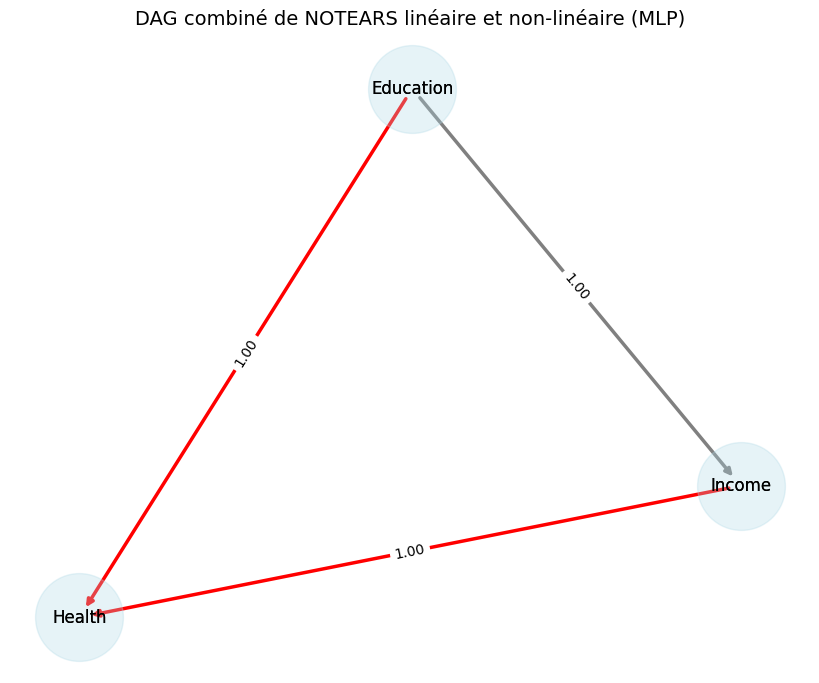

In [33]:
data2_normalized = (data2 - data2.mean()) / data2.std() # Normalisation des données

# Application de l'algorithme NOTEARS linéaire
notears = Notears() # Modèle linéaire NOTEARS
notears.learn(data2_normalized) # Apprentissage de la structure causale
W = notears.causal_matrix.T # Matrice causale, transposée pour avoir la bonne orientation

# Application de l'algorithme NOTEARS non-linéaire avec MLP
notears_nl = NotearsNonlinear(
    model_type='mlp',
    lambda1=0.001,
    lambda2=0.0001,
    max_iter=2000,
    device_type='gpu' if torch.cuda.is_available() else 'cpu'
)
notears_nl.learn(data2_normalized) # Apprentissage de la structure causale
W_nl = notears_nl.causal_matrix # Matrice causale non-linéaire

# Fusion des matrices causales
W_combined = np.abs(W) + np.abs(W_nl) # Addition des poids absolus des deux matrices

seuil = 1e-3 # Seuil pour éliminer les faibles relations
W_combined[W_combined < seuil] = 0 # Mise à zéro des relations faibles

# Création du graphe
G = nx.DiGraph()
variables = list(data2.columns)
n = len(variables)

# Ajouter des arêtes et distinguer les couleurs
for i in range(n):
    for j in range(n):
        if W[i, j] > seuil: # Si la relation linéaire est au-dessus du seuil
            G.add_edge(variables[i], variables[j], weight=W[i, j], color='gray') # Arêtes linéaires en gris
        if W_nl[i, j] > seuil: # Si la relation non-linéaire (MLP) est au-dessus du seuil
            G.add_edge(variables[i], variables[j], weight=W_nl[i, j], color='red') # Arêtes non-linéaires en rouge

# Dessin du graphe
plt.figure(figsize=(10, 8))
pos = nx.spring_layout(G, k=0.8, seed=42)

# Dessiner les noeuds, les arêtes et les labels
nx.draw_networkx_nodes(G, pos, node_size=4000, node_color="lightblue", alpha=0.3)
nx.draw_networkx_labels(G, pos, font_size=12, font_family='sans-serif')

# Récupérer les couleurs des arêtes
edge_colors = [d['color'] for u, v, d in G.edges(data=True)]

# Dessiner les arêtes avec les couleurs spécifiques
nx.draw_networkx_edges(G, pos, edge_color=edge_colors, width=2.5)
nx.draw_networkx_labels(G, pos, font_size=12, font_family='sans-serif')

# Afficher les poids des arêtes
edge_labels = {(u, v): f"{d['weight']:.2f}" for u, v, d in G.edges(data=True)}
nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels, font_size=10)

# Titre et affichage
plt.title("DAG combiné de NOTEARS linéaire et non-linéaire (MLP)", fontsize=14)
plt.axis('off')
plt.subplots_adjust(left=0.1, right=0.9, top=0.9, bottom=0.1)
plt.show()



---

